# Dataset Creation
Load data from HuggingFace AIDev dataset, filter by star count and task type, construct matched AI-Human PR pairs, and export.

In [37]:
import pandas as pd
import numpy as np
import argparse
from collections import defaultdict
from typing import Dict, List, Tuple
import sys

# ============================================================
# CONFIGURATION - Change these variables to adjust the dataset
# ============================================================
HUGGINGFACE_DATASET = "hao-li/AIDev"
MIN_STARS = 500                  # Minimum repo star count
PAIRS_PER_AGENT = 500            # Target matched pairs per AI agent
MATCH_WINDOW_DAYS = 30           # Max days apart for matched PRs
TASK_TYPES = ['feat', 'fix']     # PR task types to include
RANDOM_SEED = 42                 # For reproducible shuffling

# Output file paths
OUTPUT_MATCHED_PAIRS = 'datasets/matched_pr_pairs_in_30_days_500st.json'
OUTPUT_AI_SPLIT = 'datasets/ai_prs_split_30_days_500st_2.json'
OUTPUT_HUMAN_SPLIT = 'datasets/human_prs_split_30_days_500st_2.json'
# ============================================================

try:
    pr_df = pd.read_parquet(f"hf://datasets/hao-li/AIDev/pull_request.parquet")
    repo_df = pd.read_parquet(f"hf://datasets/hao-li/AIDev/repository.parquet")
    pr_task_type_df = pd.read_parquet(f"hf://datasets/hao-li/AIDev/pr_task_type.parquet")
    human_pr_df = pd.read_parquet(f"hf://datasets/hao-li/AIDev/human_pull_request.parquet")
    human_pr_task_type_df = pd.read_parquet(f"hf://datasets/hao-li/AIDev/human_pr_task_type.parquet")

except Exception as e:
        print(f"Error loading data: {e}")

In [38]:
print(f"len(pr_df): {len(pr_df)}")
print(pr_df.columns)
print(f"len(repo_df): {len(repo_df)}")
print(repo_df.columns)
print(f"len(pr_task_type_df): {len(pr_task_type_df)}")
print(pr_task_type_df.columns)
print(f"len(human_pr_df): {len(human_pr_df)}")
print(human_pr_df.columns)
print(f"len(human_pr_task_type_df): {len(human_pr_task_type_df)}")
print(human_pr_task_type_df.columns)

len(pr_df): 33596
Index(['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state',
       'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url',
       'html_url'],
      dtype='str')
len(repo_df): 2807
Index(['id', 'url', 'license', 'full_name', 'language', 'forks', 'stars'], dtype='str')
len(pr_task_type_df): 33596
Index(['agent', 'id', 'title', 'reason', 'type', 'confidence'], dtype='str')
len(human_pr_df): 6618
Index(['id', 'number', 'title', 'user', 'user_id', 'state', 'created_at',
       'closed_at', 'merged_at', 'repo_url', 'html_url', 'body', 'agent'],
      dtype='str')
len(human_pr_task_type_df): 6618
Index(['agent', 'id', 'title', 'reason', 'type', 'confidence'], dtype='str')


In [39]:
print("Columns in pr_task_type_df:")
print(pr_task_type_df.columns.tolist())
print("\nColumns in human_pr_task_type_df:")
print(human_pr_task_type_df.columns.tolist())
# print("\nColumns in filtered_pr_df:")
# print(filtered_pr_df.columns.tolist())
print("\nColumns in human_pr_df:")
print(human_pr_df.columns.tolist())

Columns in pr_task_type_df:
['agent', 'id', 'title', 'reason', 'type', 'confidence']

Columns in human_pr_task_type_df:
['agent', 'id', 'title', 'reason', 'type', 'confidence']

Columns in human_pr_df:
['id', 'number', 'title', 'user', 'user_id', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_url', 'html_url', 'body', 'agent']


In [27]:
# Filter repositories by star count
high_star_repos = repo_df[repo_df['stars'] > MIN_STARS]

# Get the repo IDs for these high-star repositories
high_star_repo_ids = high_star_repos['id'].tolist()

# Filter pr_df to only include PRs from these repositories
filtered_pr_df = pr_df[pr_df['repo_id'].isin(high_star_repo_ids)]

print(f"Original number of PRs: {len(pr_df)}")
print(f"Number of repos with >{MIN_STARS} stars: {len(high_star_repos)}")
print(f"Number of PRs from repos with >{MIN_STARS} stars: {len(filtered_pr_df)}")

Original number of PRs: 33596
Number of repos with >250 stars: 1980
Number of PRs from repos with >250 stars: 28410


In [40]:
# First, filter to only include configured task types
pr_task_filtered = pr_task_type_df[pr_task_type_df['type'].isin(TASK_TYPES)]
human_pr_task_filtered = human_pr_task_type_df[human_pr_task_type_df['type'].isin(TASK_TYPES)]

# Merge with filtered PR data to get repo information
# Only select the columns we need from task type to avoid duplicate 'agent' column
ai_prs = filtered_pr_df.merge(
    pr_task_filtered[['id', 'type']],
    on='id',
    how='inner'
)
human_prs = human_pr_df.merge(
    human_pr_task_filtered[['id', 'type']],
    on='id',
    how='inner'
)

# Filter to only include merged PRs (IMPORTANT: Only comparing merged PRs)
ai_prs = ai_prs[ai_prs['merged_at'].notna()]
human_prs = human_prs[human_prs['merged_at'].notna()]

print(f"AI PRs with {TASK_TYPES} type and merged: {len(ai_prs)}")
print(f"Human PRs with {TASK_TYPES} type and merged: {len(human_prs)}")
print(f"Unique agents in AI PRs: {ai_prs['agent'].unique()}")

# Verify all PRs are merged
print(f"\nVerification - All AI PRs are merged: {ai_prs['merged_at'].notna().all()}")
print(f"Verification - All Human PRs are merged: {human_prs['merged_at'].notna().all()}")

# Track used human PR IDs to ensure each is used only once
used_human_pr_ids = set()

# Store matched pairs
matched_pairs = []

# Get unique agents and determine the minimum count across agents
agent_counts = ai_prs['agent'].value_counts()
print(f"\nAgent counts in filtered AI PRs:\n{agent_counts}")

# Set max per agent (PAIRS_PER_AGENT or less if some agents have fewer)
max_per_agent = min(PAIRS_PER_AGENT, agent_counts.min())
print(f"\nTarget pairs per agent: {max_per_agent}")

from datetime import datetime, timedelta

# Convert created_at columns to datetime if not already
ai_prs['created_at'] = pd.to_datetime(ai_prs['created_at'])
human_prs['created_at'] = pd.to_datetime(human_prs['created_at'])

# Process each agent separately to ensure balance
for agent in ai_prs['agent'].unique():
    agent_ai_prs = ai_prs[ai_prs['agent'] == agent].copy()
    pairs_for_agent = 0

    # Shuffle to get random selection
    agent_ai_prs = agent_ai_prs.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    for idx, ai_pr in agent_ai_prs.iterrows():
        if pairs_for_agent >= max_per_agent:
            break

        # Find matching human PRs: same repo_url, same type, not yet used, and created within window
        matching_human = human_prs[
            (human_prs['repo_url'] == ai_pr['repo_url']) &
            (human_prs['type'] == ai_pr['type']) &
            (~human_prs['id'].isin(used_human_pr_ids)) &
            (abs((human_prs['created_at'] - ai_pr['created_at']).dt.days) <= MATCH_WINDOW_DAYS)
        ]

        if len(matching_human) > 0:
            # Take the first match
            human_pr = matching_human.iloc[0]

            # Record the pair
            matched_pairs.append({
                'ai_pr_id': ai_pr['id'],
                'human_pr_id': human_pr['id'],
                'repo_url': ai_pr['repo_url'],
                'type': ai_pr['type'],
                'agent': ai_pr['agent']
            })

            # Mark this human PR as used
            used_human_pr_ids.add(human_pr['id'])
            pairs_for_agent += 1

# Create the matched pairs dataframe
matched_pairs_df = pd.DataFrame(matched_pairs)

print(f"\nTotal matched pairs: {len(matched_pairs_df)}")
print(f"\nPairs per agent:\n{matched_pairs_df['agent'].value_counts()}")
print(f"\nPairs per type:\n{matched_pairs_df['type'].value_counts()}")

# Create final dataset with full PR information
final_dataset = matched_pairs_df.merge(
    ai_prs.add_prefix('ai_'),
    left_on='ai_pr_id',
    right_on='ai_id',
    how='left'
).merge(
    human_prs.add_prefix('human_'),
    left_on='human_pr_id',
    right_on='human_id',
    how='left'
)

print(f"\nFinal dataset shape: {final_dataset.shape}")
print(f"Columns: {final_dataset.columns.tolist()}")

# Verify final dataset only contains merged PRs
print(f"\nFinal Verification:")
print(f"  - All AI PRs in dataset are merged: {final_dataset['ai_merged_at'].notna().all()}")
print(f"  - All Human PRs in dataset are merged: {final_dataset['human_merged_at'].notna().all()}")

AI PRs with ['feat', 'fix'] type and merged: 13188
Human PRs with ['feat', 'fix'] type and merged: 2895
Unique agents in AI PRs: <ArrowStringArray>
['Claude_Code', 'Copilot', 'OpenAI_Codex', 'Cursor', 'Devin']
Length: 5, dtype: str

Verification - All AI PRs are merged: True
Verification - All Human PRs are merged: True

Agent counts in filtered AI PRs:
agent
OpenAI_Codex    9894
Devin           1413
Copilot         1188
Cursor           541
Claude_Code      152
Name: count, dtype: int64

Target pairs per agent: 152

Total matched pairs: 473

Pairs per agent:
agent
OpenAI_Codex    152
Devin           152
Copilot         121
Cursor           26
Claude_Code      22
Name: count, dtype: int64

Pairs per type:
type
feat    240
fix     233
Name: count, dtype: int64

Final dataset shape: (473, 34)
Columns: ['ai_pr_id', 'human_pr_id', 'repo_url', 'type', 'agent', 'ai_id', 'ai_number', 'ai_title', 'ai_body', 'ai_agent', 'ai_user_id', 'ai_user', 'ai_state', 'ai_created_at', 'ai_closed_at', 'ai_m

In [41]:
final_dataset.to_json(OUTPUT_MATCHED_PAIRS, orient='records', date_format='iso', indent=2)
print(f"\nDataset saved to {OUTPUT_MATCHED_PAIRS}")


Dataset saved to datasets/matched_pr_pairs_in_30_days_500st.json


In [42]:
# Split the merged dataset into AI PRs and Human PRs sets
ai_prs_split = final_dataset[[col for col in final_dataset.columns if col.startswith('ai_')]].copy()
human_prs_split = final_dataset[[col for col in final_dataset.columns if col.startswith('human_')]].copy()

# Optionally, remove the prefix for clarity
ai_prs_split.columns = [col.replace('ai_', '') for col in ai_prs_split.columns]
human_prs_split.columns = [col.replace('human_', '') for col in human_prs_split.columns]

print(f"AI PRs split shape: {ai_prs_split.shape}")
print(f"Human PRs split shape: {human_prs_split.shape}")

# Verify splits only contain merged PRs
print(f"\nSplit Verification:")
print(f"  - All AI PRs are merged: {ai_prs_split['merged_at'].notna().all()}")
print(f"  - All Human PRs are merged: {human_prs_split['merged_at'].notna().all()}")

# Save to files
ai_prs_split.to_json(OUTPUT_AI_SPLIT, orient='records', date_format='iso', indent=2)
human_prs_split.to_json(OUTPUT_HUMAN_SPLIT, orient='records', date_format='iso', indent=2)
print(f"AI and Human PRs splits saved to {OUTPUT_AI_SPLIT} and {OUTPUT_HUMAN_SPLIT}")

AI PRs split shape: (473, 16)
Human PRs split shape: (473, 15)

Split Verification:
  - All AI PRs are merged: True
  - All Human PRs are merged: True
AI and Human PRs splits saved to datasets/ai_prs_split_30_days_500st_2.json and datasets/human_prs_split_30_days_500st_2.json


# Exploratory Data Analysis
Basic visualizations and summary statistics for the matched AI-Human PR dataset.

In [45]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json

# Load the matched pairs dataset
with open(OUTPUT_MATCHED_PAIRS, 'r') as f:
    matched_data = json.load(f)
matched_df = pd.DataFrame(matched_data)

# Parse dates
for col in ['ai_created_at', 'ai_merged_at', 'ai_closed_at',
            'human_created_at', 'human_merged_at', 'human_closed_at']:
    matched_df[col] = pd.to_datetime(matched_df[col])

# --- Summary Table ---
summary = {
    'Metric': [
        'Total matched pairs',
        'Unique AI agents',
        'Unique task types',
        'Unique repositories',
        'Date range (AI PRs)',
        'Date range (Human PRs)',
    ],
    'Value': [
        len(matched_df),
        matched_df['agent'].nunique(),
        matched_df['type'].nunique(),
        matched_df['repo_url'].nunique(),
        f"{matched_df['ai_created_at'].min().date()} to {matched_df['ai_created_at'].max().date()}",
        f"{matched_df['human_created_at'].min().date()} to {matched_df['human_created_at'].max().date()}",
    ]
}
summary_table = pd.DataFrame(summary)
print("=== Dataset Overview ===")
print(summary_table.to_string(index=False))

# --- Per-agent breakdown ---
print("\n=== Per-Agent Breakdown ===")
agent_breakdown = matched_df.groupby('agent').agg(
    total_pairs=('ai_pr_id', 'count'),
    feat_pairs=('type', lambda x: (x == 'feat').sum()),
    fix_pairs=('type', lambda x: (x == 'fix').sum()),
    unique_repos=('repo_url', 'nunique'),
).reset_index()
print(agent_breakdown.to_string(index=False))

=== Dataset Overview ===
                Metric                    Value
   Total matched pairs                      473
      Unique AI agents                        5
     Unique task types                        2
   Unique repositories                      170
   Date range (AI PRs) 2024-12-25 to 2025-07-27
Date range (Human PRs) 2025-01-02 to 2025-06-28

=== Per-Agent Breakdown ===
       agent  total_pairs  feat_pairs  fix_pairs  unique_repos
 Claude_Code           22          15          7            13
     Copilot          121          46         75            48
      Cursor           26          10         16            17
       Devin          152          96         56            34
OpenAI_Codex          152          73         79            78


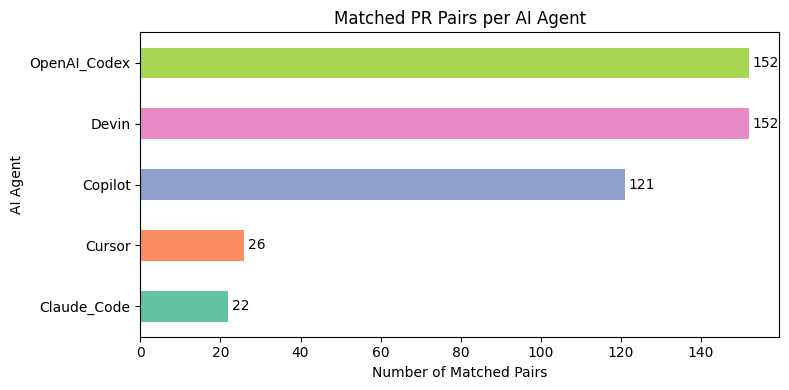

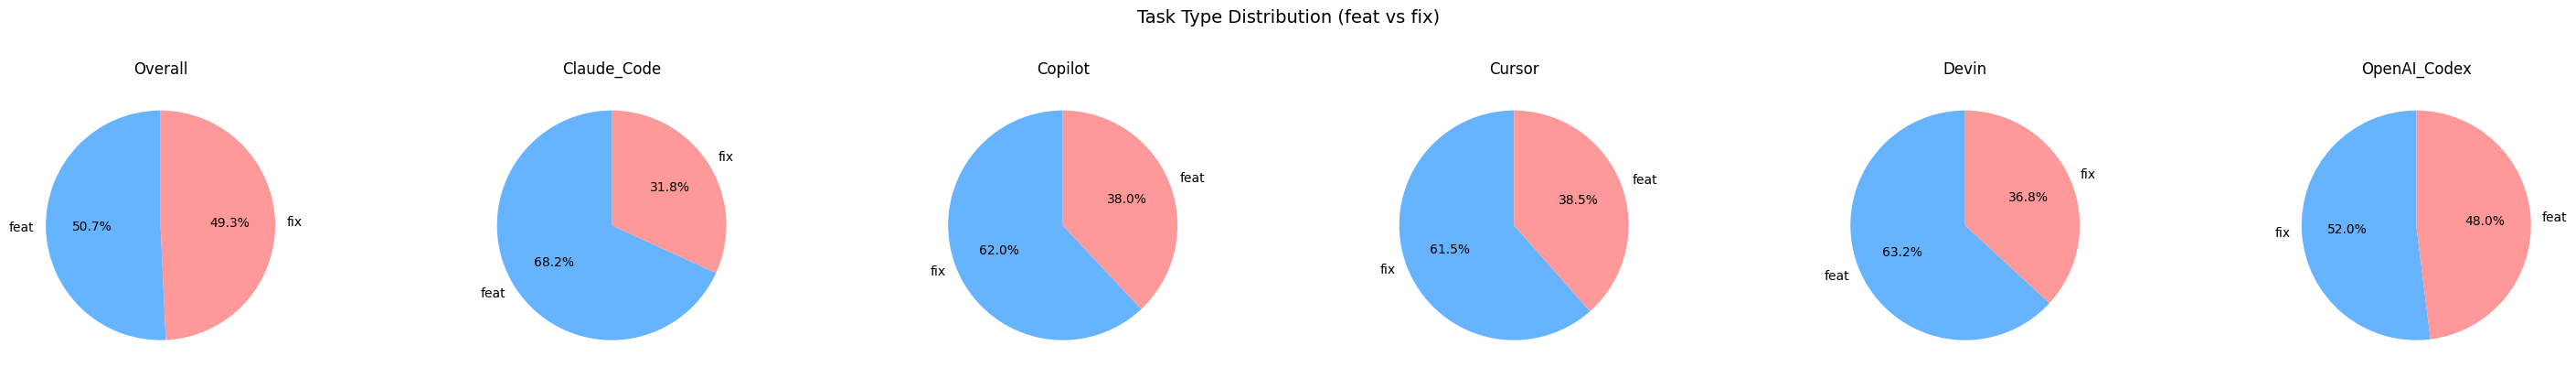

In [44]:
# --- Matched Pairs per Agent (bar chart) ---
fig, ax = plt.subplots(figsize=(8, 4))
agent_counts = matched_df['agent'].value_counts().sort_values(ascending=True)
colors = plt.cm.Set2(range(len(agent_counts)))
agent_counts.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Number of Matched Pairs')
ax.set_ylabel('AI Agent')
ax.set_title('Matched PR Pairs per AI Agent')
for i, v in enumerate(agent_counts):
    ax.text(v + 1, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

# --- Task Type Distribution (pie chart per agent + overall) ---
fig, axes = plt.subplots(1, matched_df['agent'].nunique() + 1, figsize=(5 * (matched_df['agent'].nunique() + 1), 4))
# Overall
type_counts = matched_df['type'].value_counts()
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
axes[0].set_title('Overall')
# Per agent
for i, agent in enumerate(sorted(matched_df['agent'].unique())):
    agent_types = matched_df[matched_df['agent'] == agent]['type'].value_counts()
    axes[i + 1].pie(agent_types, labels=agent_types.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
    axes[i + 1].set_title(agent)
plt.suptitle('Task Type Distribution (feat vs fix)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

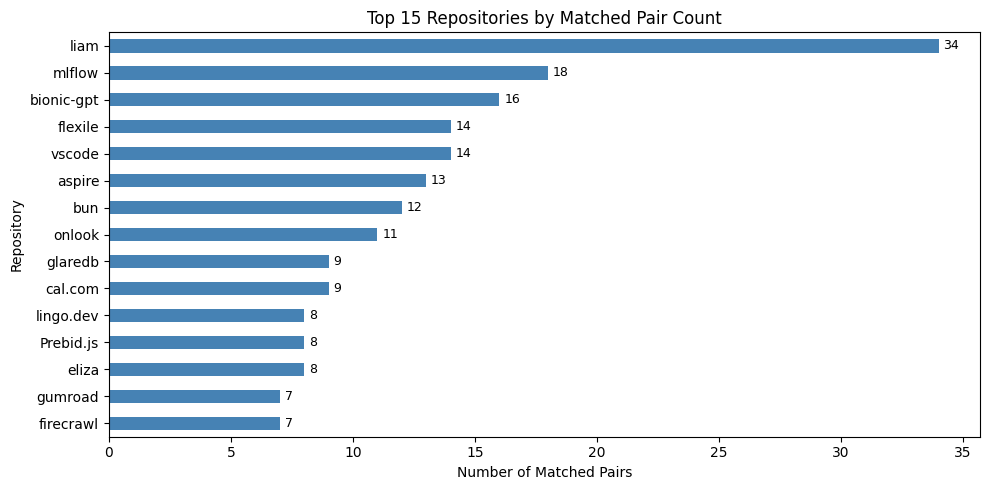

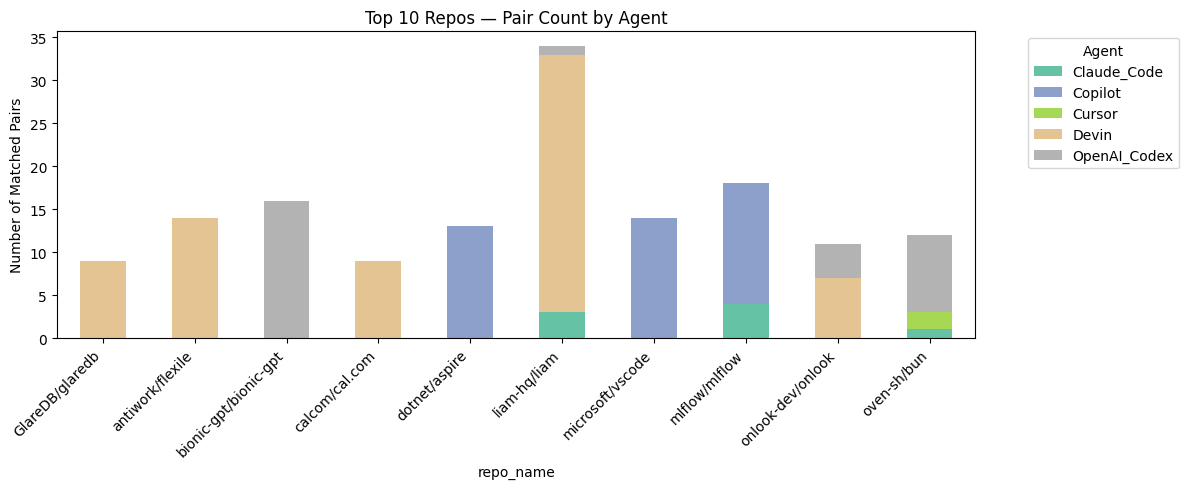

In [34]:
# --- Top 15 Repositories by Number of Matched Pairs ---
fig, ax = plt.subplots(figsize=(10, 5))
repo_counts = matched_df['repo_url'].apply(lambda x: x.split('/')[-1]).value_counts().head(15)
repo_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Matched Pairs')
ax.set_ylabel('Repository')
ax.set_title('Top 15 Repositories by Matched Pair Count')
for i, v in enumerate(repo_counts.sort_values()):
    ax.text(v + 0.2, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

# --- Repo coverage per agent (stacked bar) ---
repo_short = matched_df.copy()
repo_short['repo_name'] = repo_short['repo_url'].apply(lambda x: '/'.join(x.split('/')[-2:]))
top_repos = repo_short['repo_name'].value_counts().head(10).index
repo_agent_ct = repo_short[repo_short['repo_name'].isin(top_repos)].groupby(['repo_name', 'agent']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
repo_agent_ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_ylabel('Number of Matched Pairs')
ax.set_title('Top 10 Repos — Pair Count by Agent')
ax.legend(title='Agent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

D:\TEMP\ipykernel_1264\1170593227.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ai_months = matched_df['ai_created_at'].dt.to_period('M').value_counts().sort_index()
D:\TEMP\ipykernel_1264\1170593227.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  human_months = matched_df['human_created_at'].dt.to_period('M').value_counts().sort_index()


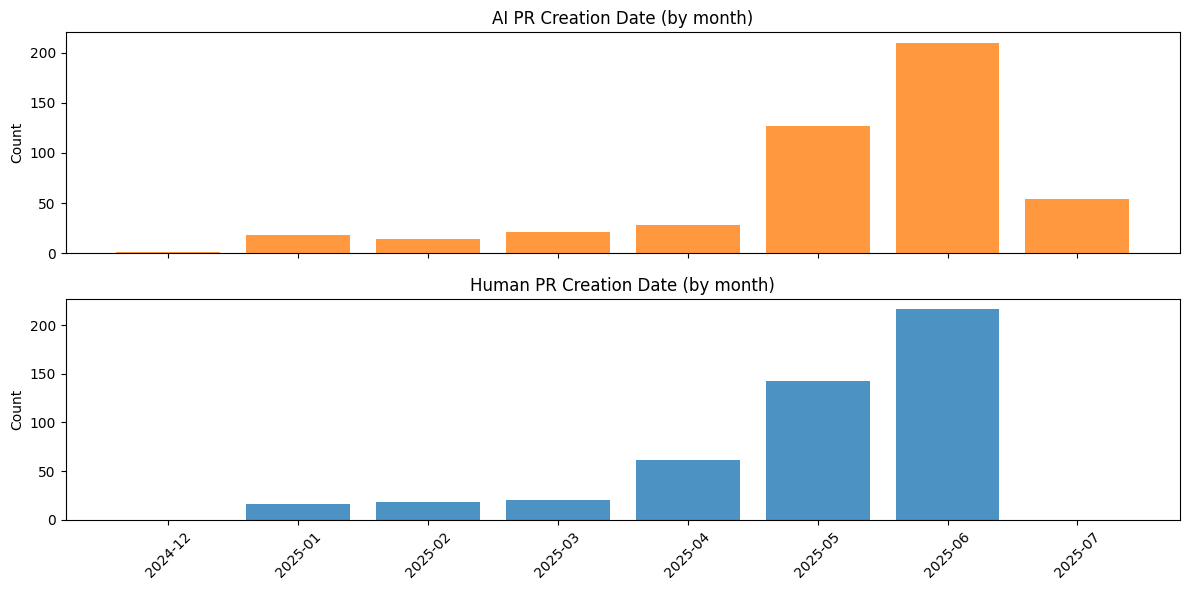

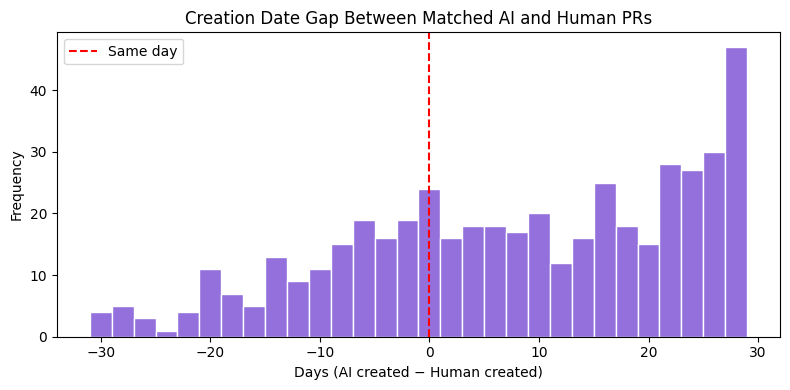

Mean creation gap: 7.3 days
Median creation gap: 9.0 days


In [35]:
# --- PR Creation Timeline ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# AI PRs by month
ai_months = matched_df['ai_created_at'].dt.to_period('M').value_counts().sort_index()
ai_months.index = ai_months.index.astype(str)
axes[0].bar(ai_months.index, ai_months.values, color='#ff7f0e', alpha=0.8)
axes[0].set_ylabel('Count')
axes[0].set_title('AI PR Creation Date (by month)')
axes[0].tick_params(axis='x', rotation=45)

# Human PRs by month
human_months = matched_df['human_created_at'].dt.to_period('M').value_counts().sort_index()
human_months.index = human_months.index.astype(str)
axes[1].bar(human_months.index, human_months.values, color='#1f77b4', alpha=0.8)
axes[1].set_ylabel('Count')
axes[1].set_title('Human PR Creation Date (by month)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# --- Days between AI and matched Human PR creation ---
matched_df['creation_gap_days'] = (matched_df['ai_created_at'] - matched_df['human_created_at']).dt.days

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(matched_df['creation_gap_days'], bins=30, color='mediumpurple', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', label='Same day')
ax.set_xlabel('Days (AI created − Human created)')
ax.set_ylabel('Frequency')
ax.set_title('Creation Date Gap Between Matched AI and Human PRs')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean creation gap: {matched_df['creation_gap_days'].mean():.1f} days")
print(f"Median creation gap: {matched_df['creation_gap_days'].median():.1f} days")

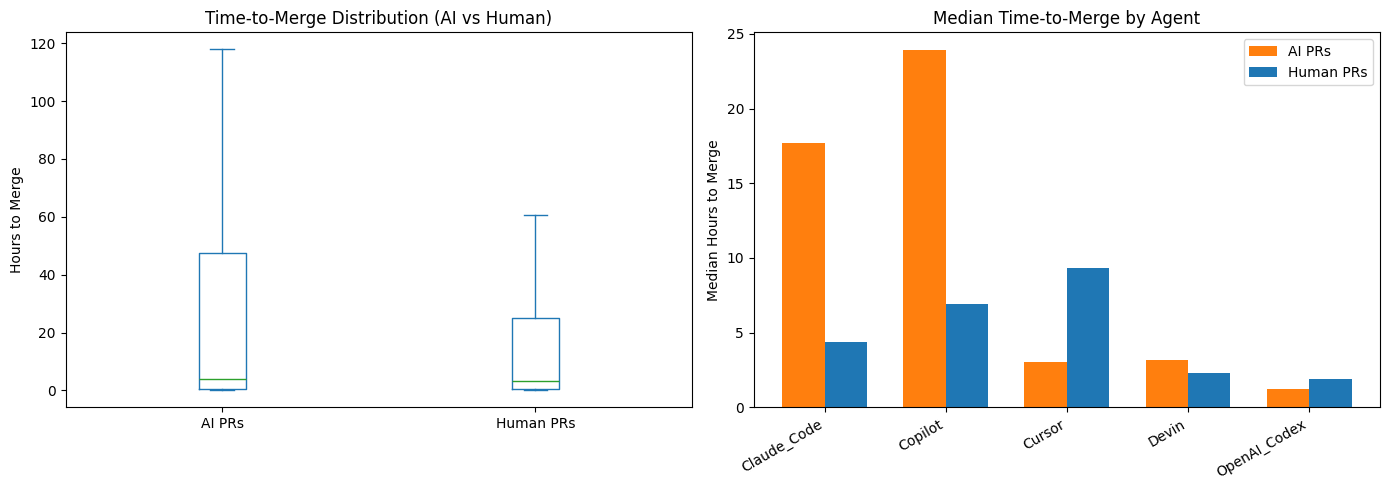

=== Time-to-Merge Summary (hours) ===
Metric AI PRs Human PRs
  Mean   61.1      34.3
Median    4.0       3.3
   Std  147.8      78.1
   Min    0.0       0.0
   Max 1376.8     869.2


In [36]:
# --- Time-to-Merge Comparison (AI vs Human) ---
matched_df['ai_time_to_merge_hrs'] = (matched_df['ai_merged_at'] - matched_df['ai_created_at']).dt.total_seconds() / 3600
matched_df['human_time_to_merge_hrs'] = (matched_df['human_merged_at'] - matched_df['human_created_at']).dt.total_seconds() / 3600

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot comparison
merge_data = pd.DataFrame({
    'AI PRs': matched_df['ai_time_to_merge_hrs'],
    'Human PRs': matched_df['human_time_to_merge_hrs']
})
# Cap at 99th percentile for visibility
cap = merge_data.quantile(0.99).max()
merge_capped = merge_data.clip(upper=cap)
merge_capped.plot(kind='box', ax=axes[0], showfliers=False)
axes[0].set_ylabel('Hours to Merge')
axes[0].set_title('Time-to-Merge Distribution (AI vs Human)')

# Per-agent median merge time
agent_merge = matched_df.groupby('agent').agg(
    ai_median_hrs=('ai_time_to_merge_hrs', 'median'),
    human_median_hrs=('human_time_to_merge_hrs', 'median')
).reset_index()
x = range(len(agent_merge))
width = 0.35
axes[1].bar([i - width/2 for i in x], agent_merge['ai_median_hrs'], width, label='AI PRs', color='#ff7f0e')
axes[1].bar([i + width/2 for i in x], agent_merge['human_median_hrs'], width, label='Human PRs', color='#1f77b4')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(agent_merge['agent'], rotation=30, ha='right')
axes[1].set_ylabel('Median Hours to Merge')
axes[1].set_title('Median Time-to-Merge by Agent')
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary stats
print("=== Time-to-Merge Summary (hours) ===")
ttm_summary = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Std', 'Min', 'Max'],
    'AI PRs': [
        f"{matched_df['ai_time_to_merge_hrs'].mean():.1f}",
        f"{matched_df['ai_time_to_merge_hrs'].median():.1f}",
        f"{matched_df['ai_time_to_merge_hrs'].std():.1f}",
        f"{matched_df['ai_time_to_merge_hrs'].min():.1f}",
        f"{matched_df['ai_time_to_merge_hrs'].max():.1f}",
    ],
    'Human PRs': [
        f"{matched_df['human_time_to_merge_hrs'].mean():.1f}",
        f"{matched_df['human_time_to_merge_hrs'].median():.1f}",
        f"{matched_df['human_time_to_merge_hrs'].std():.1f}",
        f"{matched_df['human_time_to_merge_hrs'].min():.1f}",
        f"{matched_df['human_time_to_merge_hrs'].max():.1f}",
    ],
})
print(ttm_summary.to_string(index=False))